# What is this notebook
The structure suggested by the lab is not that good for seeing all the code and understanding everything, it's easy to get lost so I made this notebook to make things clearer and have everything here!

---

# Task
- Implement an **AlexNet**
    - perform hyperparameters tuning
    - try Learning rate:
        - 0.1
        - 0.001
	    - 0.0001
    - Batch size:
	    - 16
        - 32
	    - 64

Try all combinations of: 3 learning rates × 3 batch sizes = 9 experiments --> report results.  

For each try compute:
- train loss / accuracy
- validation loss / accuracy

> ALSO TRY CHANGING THE **WEIGHT DECAY**  

# So basically:
AlexNet implementation --> do a hyper-parameter tuning (**gridsearch**) for LR, batch size and weight decay --> for each combination compute train score, validation score and test score --> track them / plot them with wandb


# ALexNet
- AlexNet architecture:

Conv1  
→ ReLU  
→ Pool  
  
Conv2  
→ ReLU  
→ Pool  
  
Conv3  
→ ReLU  
  
Conv4  
→ ReLU  
  
Conv5  
→ ReLU  
→ Pool  
  
Flatten  
  
FC1  
→ ReLU  
  
FC2  
→ ReLU  
  
FC3  

Full info about the implementation:
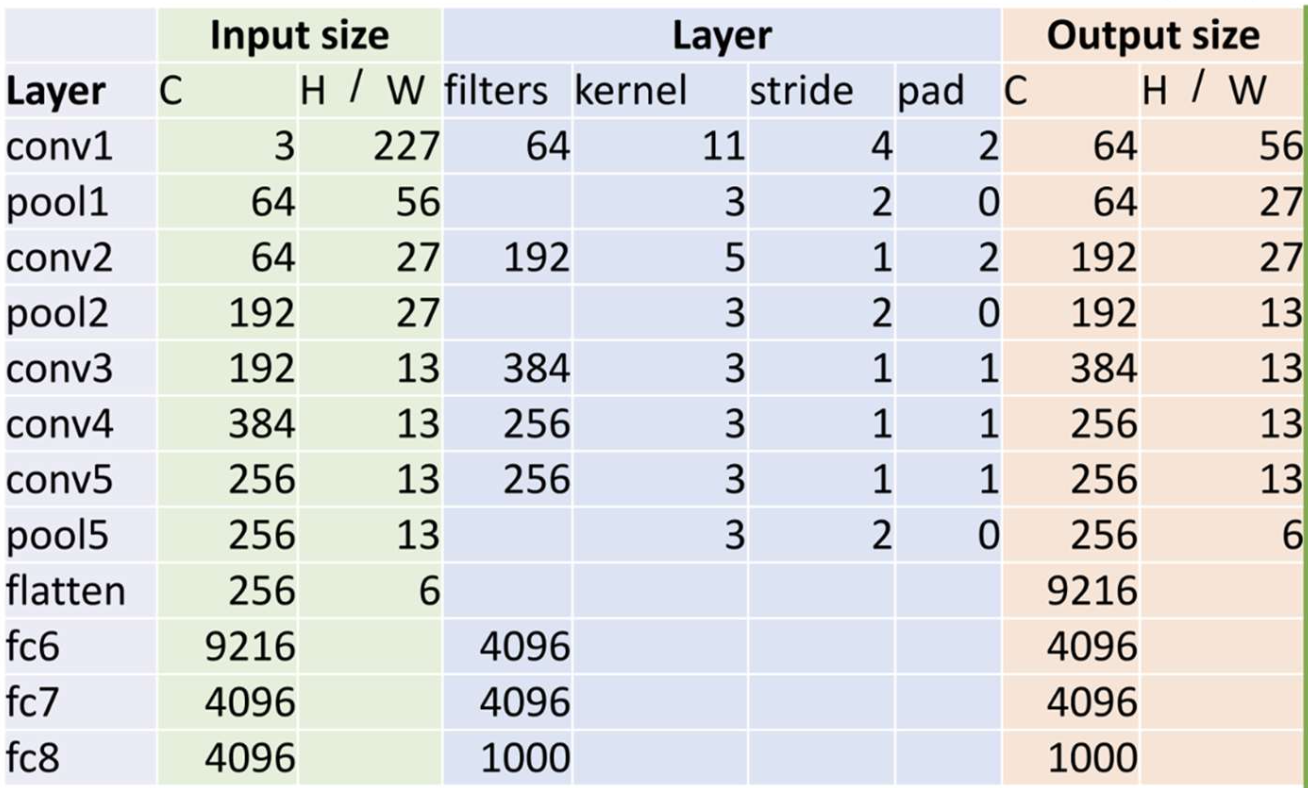

# NOTE
> We are not using the ImageNet dataset but the TinyImageNet dataset --> 200 classes instead of 1000    

> we typically use the definition 224 x 224 for images, while AlexNet uses 227 x 227  

> Original AlexNet uses **DROPOUT:**  
- dropout after fc1
- dropout after fc2


### Dropout
Dropout is a regularization technique.  
During training, it randomly “turns off” some neurons.  
Some activations are randomly set to 0.  

Why?  
Because otherwise the network can become too dependent on a few neurons, and the model starts memorizing training data too much.  
Dropout forces the model to distribute information across many neurons instead of relying on a few.  

So:
- no dropout → easier overfitting
- some dropout → better generalization
- too much dropout → model struggles to learn

> AlexNet classically uses: Dropout(p=0.5)  
> after FC1 and FC2.  

> IMPORTANT: dropout is active only during training  

---

# Work structure
data/                  # actual dataset  
dataset_dataloader/    # dataset + dataloader code  
models/                # AlexNet class  
train.py  
checkpoints/           # saved models  
eval.py  

---

# dataset + dataloader folder --> you can find the dataset + dataloader functions

In [1]:
import os
import torch
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import torch
from torch import nn

import wandb

In [ ]:
import os
import torch
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader


def get_transforms() -> T.Compose:
    """
    Build image preprocessing pipeline.
    """
    transform = T.Compose([
        T.Resize((227, 227)),
        T.ToTensor(),
        T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])
    return transform







def build_datasets(data_root: str):
    """
        Build TinyImageNet train/val datasets.

        Expected structure:
        data_root/
            tiny-imagenet-200/
                train/
                val/
    """
    transform = get_transforms()

    train_path = os.path.join(data_root, "tiny-imagenet-200", "train")
    val_path = os.path.join(data_root, "tiny-imagenet-200", "val")

    train_dataset = ImageFolder(root=train_path, transform=transform)
    val_dataset = ImageFolder(root=val_path, transform=transform)

    return train_dataset, val_dataset







def build_dataloaders(
    data_root: str,
    batch_size: int = 32,
    num_workers: int = 0,
):
    """
        Build TinyImageNet train/val dataloaders.
        dataset logic stays here, not inside train.py / eval.py (for some unknown reasons)
    """
    train_dataset, val_dataset = build_datasets(data_root)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )

    return train_loader, val_loader

---

# Models --> you can find the NN class

In [ ]:
import torch
from torch import nn


class AlexNet(nn.Module):
    def __init__(self):
        '''
            Define the CNN model:
            	•	conv1 (input_channel = 3, output_channel = 64, kernel = 11, stride = 4, padding = 2) --> input (3, 227, 227) --> output (64, 56, 56)
                •	ReLU
	            •	maxpool (kernel = 3, stride = 2, padding = 0) --> input (64, 56, 56) --> output (64, 27, 27)
                
	            •	conv2 (input_channel = 64, output_channel = 192, kernel = 5, stride = 1, padding = 2) --> input (64, 27, 27) --> output (192, 27, 27)
                •	ReLU
	            •	maxpool (kernel = 3, stride = 2, padding = 0) --> input (192, 27, 27) --> output (192, 13, 13)

	            •	conv3 (input_channel = 192, output_channel = 384, kernel = 3, stride = 1, padding = 1) --> input (192, 13, 13) --> output (384, 13, 13)
                •	ReLU

                •	conv4 (input_channel = 384, output_channel = 256, kernel = 3, stride = 1, padding = 1) --> input (384, 13, 13) --> output (256, 13, 13)
                •	ReLU
	            
                •	conv5 (input_channel = 256, output_channel = 256, kernel = 3, stride = 1, padding = 1) --> input (256, 13, 13) --> output (256, 13, 13)
                •	ReLU
                •	maxpool (kernel = 3, stride = 2, padding = 0) --> input (256, 13, 13) --> output (256, 6, 6)

                •	Flatten : (256, 6, 6) --> 256 * 6 * 6 = 9216

	            •	FC1 --> input 9216 --> output 6200
                •	ReLU

                •	FC2 --> input 6200 --> output 3200
                •	ReLU

                •	FC3 --> input 3200 --> output 200
        '''
        super(AlexNet, self).__init__()

        self.conv1 = nn.Conv2d(in_channels= 3, out_channels= 64, kernel_size= 11, stride= 4, padding= 2)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size= 3, stride= 2, padding= 0)

        self.conv2 = nn.Conv2d(in_channels= 64, out_channels= 192, kernel_size= 5, stride= 1, padding= 2)
        # self.relu = nn.ReLU()
        # self.maxpool = nn.MaxPool2d(kernel_size= 3, stride= 2, padding= 0)

        self.conv3 = nn.Conv2d(in_channels= 192, out_channels= 384, kernel_size= 3, stride= 1, padding= 1)
        # ReLU

        self.conv4 = nn.Conv2d(in_channels= 384, out_channels= 256, kernel_size= 3, stride= 1, padding= 1)
        # ReLU

        self.conv5 = nn.Conv2d(in_channels= 256, out_channels= 256, kernel_size= 3, stride= 1, padding= 1)
        # ReLU
        # maxPooling

        self.flatten = nn.Flatten()

        # slightly different in sizes from the real Alexnet as we're using a smaller dataset
        
        self.fc1 = nn.Linear(9216, 6200)
        # ReLU 

        self.fc2 = nn.Linear(6200, 3200)
        # ReLU 

        self.fc3 = nn.Linear(3200, 200)

        # ALEXNET USES DROPOUT BETWEEN FC1 AND FC2
        self.dropout = nn.Dropout(p=0.5)





    def forward(self, x):
        x = self.maxpool(self.relu(self.conv1(x)))
        x = self.maxpool(self.relu(self.conv2(x)))

        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.maxpool(self.relu(self.conv5(x)))

        x = self.flatten(x)

        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.fc3(x)

        return x


---

# train.py

In [ ]:
def train(num_epochs, AlexNet_model, train_loader, device, optimizer, loss_fn, checkpoint_path):
    for epoch in range(1, num_epochs+1):
        AlexNet_model.train()

        running_loss = 0
        total_correct_predictions = 0
        total_predictions = 0

        for x,y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            y_predicted = AlexNet_model(x)
            loss = loss_fn(y_predicted, y)
            loss.backward()
            optimizer.step()



            running_loss += loss.item()             # sum of loss of each batch in one epoch
            predictions = y_predicted.argmax(dim=1)
            correct_predictions = (predictions == y).sum().item()

            total_predictions += y.shape[0]
            total_correct_predictions += correct_predictions


        train_loss = avg_batch_loss_1_epoch = running_loss / len(train_loader)
        train_accuracy = (total_correct_predictions / total_predictions) * 100


        # keep wandb updated on the model scores so that it can keep track of training for us 
        wandb.log({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy
            })
        

        print(f"Train Epoch: {epoch}/{num_epochs} | Avg batch loss in one epoch: {train_loss:.6f} | Acc: {train_accuracy:.2f}%")

    # once the model finished training save it in the checkpoint folder
    torch.save(AlexNet_model.state_dict(), checkpoint_path)
    print(f"Saved new best model → {checkpoint_path}")





if __name__ == '__main__':
    '''
        - build dataloader --> specify data root, batch size (, number of workers)
        - specify the device (CPU / GPU)
        - build NN object
        - build loss function
        - build optimizer
        - build number of epochs
        - specify the path where you'll save the trained models --> checkpoint folder

        - to track hyperparameters / loss / gradient / ecc. --> initialise wandb + track gradients telling wandb to watch

        - train the model

        - shut wandb down
    '''

    data_root = '...'
    batch_size = 32
    num_workers = 0
    
    train_loader, val_loader = build_dataloaders(data_root=data_root, batch_size=batch_size, num_workers=num_workers)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    AlexNet_model = AlexNet().to(device)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(params=AlexNet_model.parameters(), lr=0.001)

    num_epochs = 10

    checkpoint_path = '...'


    wandb.init(
        project="lab-4-AlexNet",
        config={
            "epochs": 10,
            "batch_size": 32,
            "learning_rate": 0.001,
            "optimizer": "SGD",
            "architecture": "CustomNet",
            "dataset": "TinyImageNet"
        }
    )
    wandb.watch(AlexNet_model, loss_fn, log="all", log_freq=100)


    train(num_epochs, AlexNet_model, train_loader, device, optimizer, loss_fn, checkpoint_path)


    wandb.finish()


---

# eval.py

In [ ]:
def eval(AlexNet_model, val_loader, device, loss_fn):
    AlexNet_model.eval()

    val_loss = 0.0
    total = 0
    correct = 0
     
    with torch.no_grad():
        for x,y in val_loader:
            x = x.to(device)
            y = y.to(device)

            y_predicted = AlexNet_model(x)
            loss = loss_fn(y_predicted, y)


            val_loss += loss.item()
            prediction = y_predicted.argmax(dim=1)
            
            num_correct = (prediction == y).sum().item()
            
            total += y.shape[0]
            correct += num_correct

    val_loss = val_loss / len(val_loader)
    val_accuracy = 100.0 * correct / total

    wandb.log({
        "val_loss": val_loss,
        "val_accuracy": val_accuracy
    })

    print(f"Evaluation | Loss: {val_loss:.6f} | Acc: {val_accuracy:.2f}%")




if __name__ == '__main__':
    '''
    - build dataloader --> specify data root, batch size (, number of workers)
    - build device --> CPU or GPU
    - build NN model --> move it to device
    - UPLOAD THE TRAINED MODEL ON THE NN MODEL --> specify the CHECKPOINT PATH, from where to pick the trained model and upload it on the new model
    - Build loss function
    - to track hyperparameters / loss / gradient / ecc. --> initialise wandb + track gradients telling wandb to watch
    
    - evaluate the model

    - shut wandb down
    '''


    data_root = '...'
    batch_size = 32
    num_workers = 0
    checkpoint_path = '...'
    
    train_loader, val_loader = build_dataloaders(data_root=data_root, batch_size=batch_size, num_workers=num_workers)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    AlexNet_model = AlexNet().to(device)
    AlexNet_model.load_state_dict(torch.load(checkpoint_path, map_location=device))

    loss_fn = nn.CrossEntropyLoss()   

    wandb.init(
        project="lab-4-AlexNet",
        name="evaluation",
        config={
            "dataset": "TinyImageNet",
            "checkpoint_path": checkpoint_path
        }
    )

    eval(AlexNet_model, val_loader, device, loss_fn)

    wandb.finish()


---

---

# THIS WAS THE BASIC STRUCTURE --> WE NEED TO DO A GRIDSEARCH!!
- On LR --> 0.1, 0.001, 0.0001
- On batch size --> 16, 32, 64
- On weight decay (**regularization** to penalise big weights) --> 0.0, 1e-4, 1e-3
    - you specify it in the optimizer:

optimizer = torch.optim.Adam(AlexNet_model.parameters(), lr=0.001, **weight_decay=1e-4**)


# WE NEED TO **MANUALLY** IMPLEMENT A GRIDSEARCH ... WTF  
The logic changes a bit:
- the NN stays the same
- dataset + dataloader stays the same
- evaluation stays the same --> **INTEGRATED INSIDE THE TRAIN**
- **training** changes a bit:
    - in each epoch train the model
    - evaluate the model too --> compute validation loss and val accuracy
    - save the trained model in checkpoints only if val_accuracy > best_val_accuracy
- **HYPERPARAMETERS LOOP**
    - for lr in learning_rates:  
        - for batch_size in batch_sizes:  
            - for weight_decay in weight_decays:  
                - initialise train and validation loader
                - build model
                - build loss function
                - build optimizer
                - ... usual stuff, just inside those nested for

# evaluation

In [ ]:
import os
import torch
from torch import nn
import wandb

from dataset.dataset_and_dataloader import build_dataloaders
from models.NN_class import AlexNet


def evaluate(model, val_loader, loss_fn, device):
    model.eval()

    val_loss = 0.0
    total = 0
    correct = 0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)

            y_predicted = model(x)
            loss = loss_fn(y_predicted, y)

            val_loss += loss.item()
            predictions = y_predicted.argmax(dim=1)
            correct += (predictions == y).sum().item()
            total += y.shape[0]

    val_loss = val_loss / len(val_loader)
    val_accuracy = 100.0 * correct / total

    return val_loss, val_accuracy

# train + evaluation + best model saving

In [ ]:
def train(num_epochs, model, train_loader, val_loader, device, optimizer, loss_fn, save_path):
    best_val_accuracy = 0.0

    for epoch in range(1, num_epochs + 1):
        model.train()

        running_loss = 0.0
        total_correct_predictions = 0
        total_predictions = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            y_predicted = model(x)
            loss = loss_fn(y_predicted, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            predictions = y_predicted.argmax(dim=1)
            total_correct_predictions += (predictions == y).sum().item()
            total_predictions += y.shape[0]

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100.0 * total_correct_predictions / total_predictions

        val_loss, val_accuracy = evaluate(model, val_loader, loss_fn, device)

        wandb.log({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy
        })

        print(
            f"Epoch {epoch}/{num_epochs} | "
            f"Train Loss: {train_loss:.6f} | Train Acc: {train_accuracy:.2f}% | "
            f"Val Loss: {val_loss:.6f} | Val Acc: {val_accuracy:.2f}%"
        )

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), save_path)
            print(f"Saved best validation model -> {save_path}")

    return best_val_accuracy

# entry point with hyperparameters tuning

In [ ]:
if __name__ == "__main__":
    data_root = "data"
    num_workers = 0
    num_epochs = 10
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    learning_rates = [0.1, 0.001, 0.0001]
    batch_sizes = [16, 32, 64]
    weight_decays = [0.0, 1e-4, 1e-3]

    os.makedirs("checkpoints", exist_ok=True)

    for lr in learning_rates:
        for batch_size in batch_sizes:
            for weight_decay in weight_decays:
                run_name = f"alexnet_lr{lr}_bs{batch_size}_wd{weight_decay}"

                train_loader, val_loader = build_dataloaders(
                    data_root=data_root,
                    batch_size=batch_size,
                    num_workers=num_workers
                )

                model = AlexNet().to(device)
                loss_fn = nn.CrossEntropyLoss()

                optimizer = torch.optim.Adam(
                    params=model.parameters(),
                    lr=lr,
                    weight_decay=weight_decay
                )

                save_path = f"checkpoints/{run_name}.pth"

                wandb.init(
                    project="lab-4-AlexNet",
                    name=run_name,
                    config={
                        "epochs": num_epochs,
                        "batch_size": batch_size,
                        "learning_rate": lr,
                        "weight_decay": weight_decay,
                        "optimizer": "Adam",
                        "architecture": "AlexNet",
                        "dataset": "TinyImageNet"
                    }
                )

                best_val_accuracy = train(
                    num_epochs=num_epochs,
                    model=model,
                    train_loader=train_loader,
                    val_loader=val_loader,
                    device=device,
                    optimizer=optimizer,
                    loss_fn=loss_fn,
                    save_path=save_path
                )

                print(
                    f"Finished run: {run_name} | Best Val Acc: {best_val_accuracy:.2f}%"
                )

                wandb.finish()

---

# Just for practice
I'll implement other stuff too like:
### 1. normalization --> **nn.BatchNorm2d(...)**  

So AlexNet becomes:  
	•	conv1 -> bn1 -> relu -> maxpool  
	•	conv2 -> bn2 -> relu -> maxpool  
	•	conv3 -> bn3 -> relu  
	•	conv4 -> bn4 -> relu  
	•	conv5 -> bn5 -> relu -> maxpool  
	•	flatten  
	•	fc1 -> relu -> dropout  
	•	fc2 -> relu -> dropout  
	•	fc3  
> Typically BatchNorm is ised in the convolutional part  

##### Why batchnorm and not layernorm?
Suppose that after conv1 we have: input (N, C, H, W) --> (100, 64, 56, 56) --> 100 images, each is composed by 64 56x56 matrixes  
For one **fixed channel c**:  
$\mu_c = \text{mean over}(N, H, W)$  
$\sigma_c^2 = \text{variance over}(N, H, W)$  

**fix c → average over (N, H, W)**  
Example: input shape = (32, 64, 56, 56)  

Suppose channel 12 is an “edge detector”.  
BN takes:  
- all 32 images
- all 56 × 56 pixels
- only channel 12
and computes one mean and one variance for that channel.  

This is nice because each channel keeps its meaning:
- channel 1 = edges
- channel 7 = textures
- channel 20 = colors
- channel 45 = corners
Each feature map is normalized separately.  



### 2. data augmentation --> random rotation, random colours, random jitter, random crop, ecc:  
- RandomResizedCrop
- RandomHorizontalFlip
- ColorJitter

#### Add data augmentation:

In [ ]:
def get_transforms() -> T.Compose:
    """
    Build image preprocessing pipeline.
    """
    transform = T.Compose([
        T.Resize((227, 227)),

        ## add data augmentation part
            # random crop
            # random flip
            # random jitter
        T.RandomResizedCrop((227, 227)),
        T.RandomHorizontalFlip(p=0.5),
        T.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.1
        ),

        T.ToTensor(),
        T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])
    return transform

##### Add batch normalisation
Typical workflow:
- convoulational
- batch normalisation
- relu
- pooling

In [ ]:
import torch
from torch import nn


class AlexNet(nn.Module):
    def __init__(self):
        """
        AlexNet-style CNN + BatchNorm

        Input: (3, 227, 227)

        conv1:  (3, 227, 227)   -> (64, 56, 56)
        pool1:  (64, 56, 56)    -> (64, 27, 27)

        conv2:  (64, 27, 27)    -> (192, 27, 27)
        pool2:  (192, 27, 27)   -> (192, 13, 13)

        conv3:  (192, 13, 13)   -> (384, 13, 13)
        conv4:  (384, 13, 13)   -> (256, 13, 13)
        conv5:  (256, 13, 13)   -> (256, 13, 13)
        pool3:  (256, 13, 13)   -> (256, 6, 6)

        flatten: 256 * 6 * 6 = 9216

        fc1: 9216 -> 6200
        fc2: 6200 -> 3200
        fc3: 3200 -> 200
        """
        super(AlexNet, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=11, stride=4, padding=2)
        self.bn1 = nn.BatchNorm2d(64)

        self.conv2 = nn.Conv2d(in_channels=64, out_channels=192, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm2d(192)

        self.conv3 = nn.Conv2d(in_channels=192, out_channels=384, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(384)

        self.conv4 = nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.conv5 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(256)

        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=0)

        self.flatten = nn.Flatten()

        # Slightly different FC sizes from original AlexNet
        self.fc1 = nn.Linear(9216, 6200)
        self.fc2 = nn.Linear(6200, 3200)
        self.fc3 = nn.Linear(3200, 200)

        # AlexNet-style dropout in classifier
        self.dropout = nn.Dropout(p=0.5)






    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.maxpool(self.relu(self.bn2(self.conv2(x))))

        x = self.relu(self.bn3(self.conv3(x)))
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.maxpool(self.relu(self.bn5(self.conv5(x))))

        x = self.flatten(x)

        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.fc3(x)

        return x

---

---

# I uploaded the last versions in the python script

---

---

# NOW DO THIS ON COLAB
After you structured all the work on VS code, import the lab folder on colab and run this stuff

In [ ]:
!wget http://cs231n.stanford.edu/tiny-imagenet-200.zip
!unzip tiny-imagenet-200.zip -d data

# Before running fix the dataset file structure

In [ ]:
import os
import shutil

val_dir = 'data/tiny-imagenet-200/val'

with open(os.path.join(val_dir, 'val_annotations.txt')) as f:
    for line in f:
        fn, cls, *_ = line.split('\t')

        os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
        shutil.copyfile(
            os.path.join(val_dir, 'images', fn),
            os.path.join(val_dir, cls, fn)
        )

shutil.rmtree(os.path.join(val_dir, 'images'))

Do some checks of where you are, where was the dataset downloaded and if we fixed its internal structure

In [ ]:
!ls

In [ ]:
!ls data/tiny-imagenet-200
!ls data/tiny-imagenet-200/train | head
!ls data/tiny-imagenet-200/val | head

Check if GPUs are available

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

And start wandb

In [ ]:
!wandb login

# You're good to go with

In [ ]:
!python train.py

In [ ]:
!python eval.py